# Checking every paper number against its source: numbers-of-record audit demo

This notebook is a runnable walk-through of `eval.py` from the **numbers-of-record audit**. That artifact is a read-only, CPU-only, \$0 evaluation. It checks every number and verdict that the paper may cite against its source file in the earlier experiment artifacts, and diffs each one against the report draft (`iter_5/gen_strat/current_report.md`).

**What the audit does**

1. **Freeze** the universe of cited numbers (report tokens + curated registry claims) and hash it *before* any source is opened.
2. **Evaluate each registry claim.** It re-reads, or for tier C recomputes, the intended source value, compares it with the number written in the report under a frozen **match rule**, and classifies any mismatch: `OK`, `DRIFT_VALUE`, `WRONG_ESTIMATOR`, `WRONG_DEFINITION`, `WRONG_FOLD`, `NOT_TRACEABLE`, `VERDICT_DRIFT` or `MISSING_IN_REPORT`. To classify a mismatch it checks alternate sources (another estimator, fold or definition).
3. **Re-apply the pre-registered decision rules** verbatim, check every verdict cell in the report's tables and test 17 text assertions.
4. Build the **report-drift list**: every report line that contradicts the record, with the correct text and a severity grade.
5. Run **seeded-error injection (M5)**. It plants digit changes, CI-bound swaps, fold relabels and verdict flips in a scratch copy of the report and measures how many of them the detector finds without being told where they are.

**What is different in this demo.** The full run reads about 20 upstream artifact folders, including parquet event tables and a 3.8M-value numeric index. None of that fits in Colab. `mini_demo_data.json` therefore freezes what the detector needs:

- the full report (971 lines) and the hypothesis;
- **100 of the 319 registry claims**, including every non-OK claim, every headline claim and every known-drift claim, with each source and alternate spec **already resolved to its value**;
- the primitives of the tier-C IRR recomputation;
- the decision rules, verdict cells and assertions, as computed by `checks.py`.

The detector code below is the original `eval.py` / `audit_core.py` code, with file reads swapped for lookups into the data file. The token-level auto-scan against the numeric index is skipped, because the index is not shipped; its CI-structure check still runs.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')

In [2]:
# ---- original eval.py import block
from __future__ import annotations

import hashlib
import json
import math
import random
import re
import resource
import subprocess
import sys
import time
from collections import Counter, defaultdict
from datetime import datetime, timezone
from pathlib import Path

from loguru import logger

# ---- original audit_core.py imports
import csv
import os
from dataclasses import dataclass, field
from functools import lru_cache
from typing import Any

import numpy as np

# ---- notebook additions
import builtins
from types import SimpleNamespace
import pandas as pd
import matplotlib.pyplot as plt

WS = Path("demo_outputs")  # original: the artifact folder; the notebook writes its (small) outputs here
(WS / "results").mkdir(parents=True, exist_ok=True)
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
# original also logs to logs/run.log and sets RLIMIT_AS to 24 GB; both are omitted in the notebook

1

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/fork/run_WV-8ZZxjzY5t/round-5/evaluation-8/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"report: {len(data['report_lines'])} lines | claims: {len(data['claims'])} (of {data['reference']['n_claims_full']} in the full run) | "
      f"pre-resolved source specs: {len(data['source_values'])} | rules: {len(data['verdict_rules'])} | "
      f"verdict cells: {len(data['verdict_cells'])} | assertions: {len(data['assertions'])}")

report: 972 lines | claims: 100 (of 319 in the full run) | pre-resolved source specs: 105 | rules: 13 | verdict cells: 23 | assertions: 17


## Configuration

All tunable parameters live here.

- `N_CLAIMS`: how many of the curated registry claims to audit. The mini data holds 100; the original audit has 319.
- `N_PER_TYPE`: perturbations planted per error type in the seeded-injection test. The original uses 10, so 4 × 10 = 40 planted errors.
- `SEED` / `SEED_BLIND`: the original seeds. `SEED` is the pre-registered draw. `SEED_BLIND` is the fresh draw used for the reported M5.

In [5]:
N_CLAIMS = 100        # registry claims to audit (mini data: 100; original: 319)
N_PER_TYPE = 10       # seeded perturbations per error type (original: 10)
SEED = 20260929      # original pre-registered seed
SEED_BLIND = 20260930  # original fresh draw used for the reported (blind) M5

## 1. Audit core: the frozen match rule and the report tokenizer (`audit_core.py`)

The **match rule** decides when a reported number agrees with its source, taking into account the precision the report shows:

- **Counts:** exact equality.
- **Continuous values and CI bounds:** `|source − reported| ≤ 0.5·10^−d`, where `d` is the number of decimals shown.
- **Percentages:** the source is a fraction and is compared ×100.
- **p-values:** the rounded value must be equal, the value must fall on the same side of 0.05, and it must fall on the same side of the Holm threshold when one is attached.

`tokenize_line` finds each number in a report line and classifies it as a number, year, reference, label or hash.

The code is verbatim from `audit_core.py`. The only replacement is at the end of the cell. `read_source(relpath::key)` normally opens the source JSON or CSV. In the notebook it looks the value up in `data["source_values"]`, which was resolved from the same file when the demo data was built.

In [6]:
REPORT_REL = data['report_rel']
HYPO_REL = data['hypo_rel']
# artifact id -> workspace (run-root-relative); original: a literal dict in audit_core.py
ARTIFACTS: dict[str, str] = data['artifacts']
PATH_TO_ART = {v: k for k, v in ARTIFACTS.items()}

# ---------------------------------------------------------------- flags / rule
FLAGS = ["OK", "DRIFT_VALUE", "WRONG_ESTIMATOR", "WRONG_DEFINITION", "WRONG_FOLD",
         "NOT_TRACEABLE", "VERDICT_DRIFT", "MISSING_IN_REPORT"]
MATCH_RULE = {
    "counts_and_n_G": "exact equality after removing thousands separators",
    "continuous_and_ci_bounds": "|source - reported| <= 0.5 * 10^-d (+1e-9), d = decimals shown in the report; "
                                 "percentages compare source*100 at the shown decimals",
    "p_values": "equal after rounding the source to the reported significant figures (or 'p < x' holds), AND same side "
                "of 0.05, AND same side of the Holm threshold when one is attached to the claim",
    "verdicts": "the verdict string must equal the one the decision rule gives on the source numbers",
    "ci_structure": "a reported 'x [lo, hi]' must satisfy lo <= hi and lo <= x <= hi at the shown precision",
}
FLAG_DEFS = {
    "OK": "value/verdict matches its intended source under the match rule",
    "DRIFT_VALUE": "a source exists for the intended quantity but the reported value differs and matches no alternative",
    "WRONG_ESTIMATOR": "the number is real but comes from a different estimator/spec/model than the one the text names",
    "WRONG_DEFINITION": "the number or sentence is real but is given a wrong meaning (e.g. OR read as a risk ratio)",
    "WRONG_FOLD": "screen number labelled held-out (or the reverse), or MeSH/main mixed",
    "NOT_TRACEABLE": "no file contains the number; a replacement value is given or the number is dropped",
    "VERDICT_DRIFT": "the verdict stated differs from what the frozen decision rule gives on the source numbers",
    "MISSING_IN_REPORT": "a number of record (hypothesis evidence list / artifact output) that the report never states",
}

NUM_RE = re.compile(r"(?<![\w.\^])([−\-+]?)(\d[\d,]*(?:\.\d+)?|\.\d+)(?:\s?[×x]\s?10\^?([−\-]?\d+)|e([−\-]?\d+))?(%?)(?![\w])")
MINUS = str.maketrans({"−": "-", "–": "-", "‑": "-"})


@dataclass
class Reported:
    """A reported number as written, with its precision."""
    text: str
    value: float
    decimals: int
    sig: int
    is_pct: bool
    is_sci: bool
    lt: bool = False  # 'p < x'


def parse_reported(s: str) -> Reported | None:
    """Parse '1,544', '−0.391', '26%', '9.7e-5', '1e-5', '< 0.001', '1.4e-13'."""
    t = s.strip().translate(MINUS).replace(" ", "").replace(" ", "")
    lt = False
    if t.startswith("<"):
        lt, t = True, t[1:]
    if t.startswith("≤"):
        lt, t = True, t[1:]
    is_pct = t.endswith("%")
    t = t.rstrip("%")
    m = re.fullmatch(r"([+\-]?)(\d[\d,]*(?:\.\d+)?|\.\d+)(?:e([+\-]?\d+)|[×x]10\^?([+\-]?\d+))?", t)
    if not m:
        return None
    sign, mant, e1, e2 = m.groups()
    mant_clean = mant.replace(",", "")
    exp = e1 or e2
    val = float(mant_clean) * (10 ** int(exp) if exp else 1.0)
    if sign == "-":
        val = -val
    dec = len(mant_clean.split(".")[1]) if "." in mant_clean else 0
    digits = mant_clean.replace(".", "").lstrip("0")
    sig = max(1, len(digits))
    if exp:
        dec = dec - int(exp)
    return Reported(text=s.strip(), value=val, decimals=dec, sig=sig, is_pct=is_pct, is_sci=bool(exp), lt=lt)


def round_sig(x: float, sig: int) -> float:
    if x == 0 or not math.isfinite(x):
        return x
    return round(x, sig - int(math.floor(math.log10(abs(x)))) - 1)


def match_value(rep: Reported, src: float, kind: str = "cont", holm_threshold: float | None = None,
                sign_mode: str = "signed") -> bool:
    """Frozen match rule (see MATCH_RULE)."""
    if src is None or (isinstance(src, float) and not math.isfinite(src)):
        return False
    src = float(src)
    rv = rep.value
    if sign_mode == "abs":
        src, rv = abs(src), abs(rv)
    if kind == "count":
        return abs(src - rv) < 1e-9
    if kind == "pct":  # source is a fraction, report in percent
        src = src * 100.0
        return abs(src - rv) <= 0.5 * 10 ** (-rep.decimals) + 1e-9
    if kind == "p":
        if rep.lt:
            ok = src < rv + 1e-15
        elif rep.is_sci or rv < 0.001:
            ok = abs(round_sig(src, rep.sig) - rv) <= 1e-12 * max(1.0, abs(rv)) or \
                abs(src - rv) <= 0.5 * 10 ** (-rep.decimals) + 1e-15
        else:
            ok = abs(src - rv) <= 0.5 * 10 ** (-rep.decimals) + 1e-12 or abs(round_sig(src, rep.sig) - rv) < 1e-12
        same_side = (src < 0.05) == (rv < 0.05) or rep.lt
        if holm_threshold is not None:
            same_side = same_side and ((src < holm_threshold) == (rv < holm_threshold) or rep.lt)
        return ok and same_side
    # continuous
    return abs(src - rv) <= 0.5 * 10 ** (-rep.decimals) + 1e-9

# ---------------------------------------------------------------- source access
# DEMO: the original read_source(spec) opens <run>/<relpath> and walks `key` (JSON path or CSV row filter).
# The value of every spec used by the curated claims was resolved from those files when mini_demo_data.json was built.
def read_source(spec: str) -> Any:
    rec = data['source_values'][spec]
    if 'error' in rec:
        raise getattr(builtins, rec['error'], KeyError)(rec['message'])
    return rec['value']


def read_report(path: Path | None = None) -> list[str]:
    return list(data['report_lines'])  # original: (RUN_ROOT / REPORT_REL).read_text().split('\n')


@dataclass
class Token:
    line: int  # 1-based
    col: int
    text: str
    rep: Reported
    kind: str  # 'year', 'ref', 'num'
    section: str = ""


YEAR_OK = range(1985, 2031)


def tokenize_line(text: str, lineno: int) -> list[Token]:
    toks: list[Token] = []
    if re.match(r"^\[\d+\]\s", text):  # reference list entries
        return toks
    for m in NUM_RE.finditer(text):
        sign, mant, e_x, e_e, pct = m.groups()
        s = (sign or "") + mant + (f"e{(e_x or e_e)}" if (e_x or e_e) else "") + (pct or "")
        rep = parse_reported(s)
        if rep is None:
            continue
        start = m.start()
        before = text[max(0, start - 12):start]
        after = text[m.end():m.end() + 3]
        kind = "num"
        if re.search(r"\[$", before) and after.startswith("]") and "." not in mant and "," not in text[m.end():m.end() + 1]:
            kind = "ref"
        elif re.search(r"(Table|Artifact|Iteration|iteration|Figure|activity|Activity|F\d|M|m|R|E|S|G|W|k|C|D|H|Y)\s?$", before) and "." not in mant and not pct:
            # 'Table 16', 'Artifact 12', 'M3', 'R1', 'E4', 'G2', 'W2', 'Y3' identifiers
            kind = "label" if re.search(r"(Table|Artifact|Iteration|iteration|Figure|activity|Activity)\s$", before) or re.search(r"[A-Za-z]$", before) else "num"
        if kind == "num" and "." not in mant and "," not in mant and not pct and rep.value in YEAR_OK and not sign:
            kind = "year"
        if kind == "num" and re.search(r"(sha|SHA|hash|\.\.\.)", text[max(0, start - 30):m.end() + 6]) and re.search(r"[0-9a-f]{6,}", text[max(0, start - 10):m.end() + 10]):
            kind = "hash"
        toks.append(Token(line=lineno, col=start, text=s, rep=rep, kind=kind))
    return toks


def sections(lines: list[str]) -> list[tuple[int, int, str]]:
    """(start, end, heading) 1-based inclusive ranges for '#'/'##'/'###' headings."""
    heads = [(i + 1, l.strip("# ").strip()) for i, l in enumerate(lines) if l.startswith("#")]
    out = []
    for j, (s, h) in enumerate(heads):
        e = heads[j + 1][0] - 1 if j + 1 < len(heads) else len(lines)
        out.append((s, e, h))
    return out


def iteration_of_line(lines: list[str], lineno: int) -> int:
    it = 0
    for i in range(lineno):
        m = re.match(r"^# Iteration (\d)", lines[i])
        if m:
            it = int(m.group(1))
    return it



# the eval code below calls these as AC.<name> (audit_core imported as AC)
AC = SimpleNamespace(REPORT_REL=REPORT_REL, HYPO_REL=HYPO_REL, ARTIFACTS=ARTIFACTS, FLAGS=FLAGS, MATCH_RULE=MATCH_RULE, FLAG_DEFS=FLAG_DEFS,
                     MINUS=MINUS, parse_reported=parse_reported, match_value=match_value, read_source=read_source,
                     read_report=read_report, tokenize_line=tokenize_line, sections=sections, iteration_of_line=iteration_of_line)

# quick look at the match rule on two report strings
print(parse_reported('−0.391'), match_value(parse_reported('0.85'), 0.8503, 'p'), match_value(parse_reported('0.48'), 0.8503, 'p'))

Reported(text='−0.391', value=-0.391, decimals=3, sig=3, is_pct=False, is_sci=False, lt=False) True False


## 2. Registry, pre-resolved sources and the eval constants

`CLAIMS` is the curated registry (`registry.py`). Each claim records:

- the **intended source** (`relpath::key`, or `recompute:<name>` for a tier-C recomputation);
- **alternates**, each labelled with the flag it implies when it is the value that matches, such as `WRONG_ESTIMATOR` or `WRONG_DEFINITION`;
- a regex that locates the reported value near a hint line of the report.

`checks.RECOMPUTE[...]` normally recomputes a tier-C value from row-level files. Here it returns the value computed at build time. `checks.verdict_rules()`, `verdict_cells()` and `assertions()` return the rule, cell and assertion records that `checks.py` produced from the source files: the verbatim rule quote, the outcome the rule gives on the source numbers, and the regex that finds the report's statement.

The constants that follow (`KNOWN_DRIFT`, `find_rep`, `fmt`) are verbatim from `eval.py`. `KNOWN_DRIFT` is the plan's list of known errors in the report; the detector must find all 12 of them.

In [7]:
CLAIMS = data['claims'][:N_CLAIMS]  # original: from registry import CLAIMS (319 claims)
checks = SimpleNamespace(
    RECOMPUTE={spec.split(':', 1)[1]: (lambda s=spec: AC.read_source(s)) for spec in data['source_values'] if spec.startswith('recompute:')},
    verdict_rules=lambda: data['verdict_rules'], verdict_cells=lambda: data['verdict_cells'], assertions=lambda: data['assertions'])
print(f'{len(CLAIMS)} claims; blocks {dict(Counter(c["block"] for c in CLAIMS))}; tiers {dict(Counter(c["tier"] for c in CLAIMS))}')

SEED = 20260929
SEED_BLIND = 20260930  # fresh draw used for the reported (blind) M5 after the detector fix; see README
KNOWN_DRIFT = {  # the plan's known-drift list (gate: recall must be 100%)
    "K01_rq1_rescue_summary": "RQ1 rescue in the summary paragraph (line ~7)",
    "K02_learned_heading": "'What we have learned' heading rescues RQ1 (line ~867)",
    "K03_fig_methodology": "fig_methodology description (rescued R1, OR 3.14, placement)",
    "K04_26of27": "'26 of 27' robustness (lines ~486 note vs ~551)",
    "K05_primary_CT_p": "primary CT p 0.48 vs 0.85",
    "K06_83pct": "'83% single-paper'",
    "K08_table20": "Table 20's 1.14 / 1.09",
    "K09_or_31x": "'3.1x more likely'",
    "K10_neg_plac_matching": "NEG/PLAC/matching descriptions",
    "K11_k2_mesh": "'k = 2 replicates on ... MeSH'",
    "K12_mesh_leadlag": "'directionally consistent' MeSH lead-lag",
    "K14_establishment": "'host-native partners predict establishment' while EST_bin is null",
}
EXTRA_KNOWN = {"K13_constraint_mixed": "Table 20c constraint row mixes pooled-panel screen with event-study held-out (review item)"}
BLOCK_ORDER = ["D2", "MeSH", "RQ1", "descriptive", "adopter", "data"]


# ============================================================ helpers
def sha(s: str | bytes) -> str:
    return hashlib.sha256(s if isinstance(s, bytes) else s.encode()).hexdigest()


def find_rep(lines: list[str], hint: int, regex: str) -> tuple[int, str] | None:
    """Locate a reported number by regex; the match nearest the hint line wins."""
    rx = re.compile(regex)
    best = None
    for i, l in enumerate(lines):
        m = rx.search(l)
        if m:
            d = abs(i + 1 - hint)
            if best is None or d < best[0]:
                best = (d, i + 1, m.group(1))
    return (best[1], best[2]) if best else None


def fmt(v) -> str:
    if v is None:
        return ""
    if isinstance(v, float):
        if v != 0 and (abs(v) < 1e-3 or abs(v) >= 1e6):
            return f"{v:.3e}"
        return f"{v:.6g}"
    return str(v)

100 claims; blocks {'D2': 30, 'MeSH': 12, 'RQ1': 26, 'descriptive': 10, 'adopter': 16, 'data': 6}; tiers {'C': 31, 'R': 69}


## 3. Step 0: freeze the universe before any source is opened

`build_universe` collects three things:

- every numeric token in the report;
- the reported value and hypothesis value that each registry claim's regex finds;
- every verdict word in the report.

`freeze` hashes the result and writes the spec (match rule, flag taxonomy, known-drift list, injection design) **before** any source value is read. In the original, this ordering is what makes the audit pre-registered.

Demo notes:
- The hash covers only the `N_CLAIMS` claims, so it differs from the original `47f194ab…`.
- The hypothesis is hashed from its text, not from its JSON file.

In [8]:
def build_universe(lines: list[str], hypo_text: str) -> dict:
    toks = []
    for i, l in enumerate(lines):
        for t in AC.tokenize_line(l, i + 1):
            toks.append(dict(line=t.line, col=t.col, text=t.text, kind=t.kind))
    reg = []
    for c in CLAIMS:
        rv = find_rep(lines, c["rep"][0], c["rep"][1]) if c["rep"] else None
        hv = None
        if c.get("hyp"):
            m = re.search(c["hyp"], hypo_text)
            hv = m.group(1) if m else None
        reg.append(dict(id=c["id"], block=c["block"], report_line=rv[0] if rv else None, report_value=rv[1] if rv else None,
                        hyp_value=hv, src=c["src"], alt=[a[1] for a in c["alt"]]))
    verdict_words = [(i + 1, w) for i, l in enumerate(lines) for w in re.findall(
        r"\b(CONFIRMED|DEAD|GRAFTING|NEITHER|REPLICATED|NULL|MIXED|TRIGGERED|NOT MET|PASS|FAIL|SUPPORT|NOT SUPPORTED|R1_DEAD)\b", l)]
    return dict(tokens=toks, registry=reg, verdict_words=verdict_words)


def freeze(lines: list[str], hypo_text: str) -> dict:
    uni = build_universe(lines, hypo_text)
    uni_json = json.dumps(uni, sort_keys=True, ensure_ascii=False)
    spec = dict(
        artifact="gen_art_evaluation_8 (iteration 5, FIX slot): numbers-of-record audit",
        frozen_utc=datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ"),
        note="Frozen before any source file is opened: universe of cited numbers, match rule, flag taxonomy, known-drift list, "
             "seeded-injection design. Sources are only read after this file is written.",
        report=AC.REPORT_REL, report_sha256=sha("\n".join(lines)),  # original: sha of the report file bytes
        hypothesis=AC.HYPO_REL, hypothesis_sha256=sha(hypo_text),  # original: sha of the hypothesis JSON file
        universe_sha256=sha(uni_json), n_report_tokens=len(uni["tokens"]),
        n_report_tokens_by_kind=dict(Counter(t["kind"] for t in uni["tokens"])),
        n_registry_claims=len(uni["registry"]), n_verdict_words=len(uni["verdict_words"]),
        match_rule=AC.MATCH_RULE, flags=AC.FLAG_DEFS, known_drift=KNOWN_DRIFT, extra_known=EXTRA_KNOWN,
        severity_grades={"VERDICT-CHANGING": "the correct number/verdict changes a significance side, a CI-excludes-null statement or a decision-rule outcome",
                         "NUMBER-ONLY": "value differs but no conclusion changes", "WORDING": "definition/label/scope wording"},
        tiers={"R": "re-read from a summary JSON/CSV", "C": "recomputed from row-level files or from primitive quantities (Holm, IVW, counts, prevalences)"},
        seeded_injection=dict(seed=SEED, n_per_type=N_PER_TYPE, types=["digit_change", "ci_bound_swap", "estimator_fold_relabel", "verdict_flip"],
                              target_recall=0.95, blind="the detector receives only the perturbed text"),
        independent_rederivation=dict(n_sample=50, min_per_block=8, plus="all headline/verdict-bearing numbers", seed=SEED),
    )
    (WS / "results" / "audit_universe.json").write_text(uni_json)
    (WS / "results" / "audit_spec.json").write_text(json.dumps(spec, indent=2, ensure_ascii=False))
    spec["_audit_spec_sha256"] = sha((WS / "results" / "audit_spec.json").read_bytes())
    logger.info(f"FROZEN universe sha256 {spec['universe_sha256'][:16]} ({len(uni['tokens'])} tokens, {len(uni['registry'])} claims) at {spec['frozen_utc']}")
    return dict(spec=spec, universe=uni)


# ---- main(), first lines
t0 = time.time()
lines = AC.read_report()
hypo_text = data['hypothesis']  # original: json.loads((AC.RUN_ROOT / AC.HYPO_REL).read_text())['hypothesis']
frz = freeze(lines, hypo_text)  # nothing from an artifact has been opened before this line
results: dict = dict(spec=frz['spec'])

21:17:47|INFO   |FROZEN universe sha256 87d3c2bbc50c431c (1534 tokens, 100 claims) at 2026-09-29T21:17:47Z


## 4. Step 1: evaluate each registry claim

`evaluate_claim` runs these steps for each claim:

1. Find the reported value in the report: the regex match nearest the hint line.
2. Read the intended source value.
3. Compare the two under the match rule.
4. If they do not match, try the alternates. The first alternate that matches gives the flag, for example `WRONG_ESTIMATOR`. If none matches, the flag is `DRIFT_VALUE`, or `NOT_TRACEABLE` when there is no usable source.
5. For the tier-C headline IRRs, recompute the value from primitives. A reported value that agrees with the summary file but not with the recompute is still flagged.

`tierc_irr` computes IRR per SD as `exp(b · SD(A_cont))`, with the CI from `b ± 1.96·se`. The original reads row-level parquet event tables, prunes the fixed-effect groups (`_prune`) and takes the SD of `A_cont`. That pruning was run when the demo data was built, so here `b`, `se` and the pruned-sample SD come from `data["tierc_primitives"]`. The arithmetic is unchanged.

In [9]:
# ============================================================ step 1: evaluate registry claims
def source_value(spec: str):
    if spec.startswith("recompute:"):
        return checks.RECOMPUTE[spec.split(":", 1)[1]]()
    return AC.read_source(spec)


TIERC_IRR = {  # headline IRR rows recomputed from primitives b, se and the row-level SD of A_cont
    "d2.scr.cop.irr": ("screen", "irr"), "d2.scr.cop.lo": ("screen", "lo"), "d2.scr.cop.hi": ("screen", "hi"),
    "d2.ho.cop.irr": ("heldout", "irr"), "d2.ho.cop.irr_sum": ("heldout", "irr"), "d2.ho.cop.lo": ("heldout", "lo"), "d2.ho.cop.hi": ("heldout", "hi"),
    "g4.R2.irr": ("mesh", "irr"), "g4.R2.irr_sum": ("mesh", "irr"), "g4.R2.lo": ("mesh", "lo"), "g4.R2.hi": ("mesh", "hi"),
}


def _prune(d, fes, y="Y_strict"):
    """Drop FE groups with all-zero outcome or a single event until stable (PPML separation / singletons)."""
    while True:
        n = len(d)
        for f in fes:
            d = d[d.groupby(f)[y].transform("sum") > 0]
            d = d[d.groupby(f)[y].transform("size") > 1]
        if len(d) == n:
            return d


def tierc_irr(which: str, part: str) -> tuple[float, str]:
    """IRR/SD recomputed as exp(b * SD(A_cont)) with SD over the reconstructed co-primary estimation sample
    (row-level events, concept + e + d FE groups pruned for all-zero outcomes and singletons); CI from b +- 1.96 se."""
    z = 1.959963984540054
    # DEMO: the original loads b, se from the model summary and the row-level parquet events, then
    # p = _prune(ev, ["concept_id", "e", "d"]); sd = p.A_cont.std(). Those primitives were computed at build time.
    P = data["tierc_primitives"][which]
    b, se, sd, src = P["b"], P["se"], P["sd"], P["src"]
    val = {"irr": math.exp(b * sd), "lo": math.exp((b - z * se) * sd), "hi": math.exp((b + z * se) * sd)}[part]
    return val, f"exp(b*SD) with SD over the reconstructed estimation sample (N={P['N']}, G={P['G']}) of {src}"


def evaluate_claim(c: dict, lines: list[str], hypo_text: str) -> dict:
    out = dict(id=c["id"], block=c["block"], claim=c["claim"], fold_label=c["fold"], estimator=c["estimator"], artifact=c["art"],
               tier=c["tier"], headline=c["headline"], known=c.get("known") or "")
    rv = find_rep(lines, c["rep"][0], c["rep"][1]) if c["rep"] else None
    hv = None
    if c.get("hyp"):
        m = re.search(c["hyp"], hypo_text)
        hv = m.group(1) if m else None
    out.update(report_line=rv[0] if rv else "", report_value=rv[1] if rv else "", hyp_value=hv or "")
    out["source"] = c["src"] or ""
    sv, err = None, ""
    if c["src"]:
        try:
            sv = source_value(c["src"])
        except (KeyError, IndexError, FileNotFoundError, ValueError, TypeError, StopIteration) as e:
            err = f"{type(e).__name__}: {e}"
            logger.warning(f"source read failed for {c['id']}: {err}")
    out["source_value"] = sv if not isinstance(sv, str) else sv
    out["source_error"] = err
    out["recomputed"] = ""
    out["recompute_method"] = "recompute function (row-level / primitives)" if (c["src"] or "").startswith("recompute:") else "re-read"
    if c["id"] in TIERC_IRR:
        try:
            v, how = tierc_irr(*TIERC_IRR[c["id"]])
            out["recomputed"], out["recompute_method"] = v, how
        except (KeyError, FileNotFoundError, ValueError, TypeError) as e:
            out["recompute_method"] = f"tier-C recompute failed: {e}"
            out["tier"] = "R"
    compare_str = out["report_value"]
    rep = AC.parse_reported(compare_str) if compare_str else None
    kind = c["kind"]
    if rep is not None and rep.is_pct and kind == "cont":
        kind = "pct"
    if kind == "pctval":
        kind = "cont"

    def m(val) -> bool:
        return rep is not None and isinstance(val, (int, float)) and AC.match_value(rep, float(val), kind, c.get("holm"), c.get("sign", "signed"))

    flag, alt_used = None, ""
    if rep is None:
        flag = "MISSING_IN_REPORT"
        agrees = None
    elif c["src"] and not err and m(sv):
        flag = "OK"
    else:
        for cat, aspec in c["alt"]:
            try:
                av = source_value(aspec)
            except (KeyError, IndexError, FileNotFoundError, ValueError, TypeError) as e:
                logger.warning(f"alt read failed {c['id']}: {e}")
                continue
            if m(av):
                flag, alt_used = cat, f"{aspec} = {fmt(av)}"
                if cat == "OK":
                    out["source"], out["source_value"] = aspec, av
                break
        if flag is None:
            flag = "NOT_TRACEABLE" if (not c["src"] or err) else "DRIFT_VALUE"
    if c["tier"] == "C" and out["recomputed"] != "" and rep is not None and flag == "OK":
        if not m(out["recomputed"]):
            flag = "DRIFT_VALUE"
            alt_used = f"tier-C recompute disagrees: {fmt(out['recomputed'])}"
    # where the text is only in the hypothesis, still check the hypothesis value
    hyp_ok = ""
    if hv:
        hr = AC.parse_reported(hv)
        if hr is not None and sv is not None and isinstance(sv, (int, float)):
            hk = "pct" if (hr.is_pct and c["kind"] == "cont") else ("cont" if c["kind"] == "pctval" else c["kind"])
            hyp_ok = str(AC.match_value(hr, float(sv), hk, c.get("holm"), c.get("sign", "signed")))
    if flag == "MISSING_IN_REPORT" and not hv and c["src"]:
        out["note"] = "number of record (artifact output) never stated in the report"
    else:
        out["note"] = ""
    out.update(flag=flag, alt_match=alt_used, hyp_agrees=hyp_ok, replacement=c.get("replacement") or "",
               traced=bool((c["src"] and not err) or flag == "OK"))
    return out

## 5. Step 2: decision rules, verdict cells, fold labels and text assertions

- **`evaluate_verdicts`** takes each pre-registered decision rule, quoted verbatim from the iteration 2–4 strategy files, and applies it to the audited source numbers. The resulting outcome must be the verdict the report states. For R1 ("R1 dead if the pooled-panel held-out row fails"), the report never says R1_DEAD; the lines that rescue RQ1 are marked as drift instead.
- **`evaluate_vcells`** checks every verdict word written in a report table row, such as PASS/FAIL or GRAFTING, against its source.
- **`fold_check`** confirms that an `OK` number sits in a clause labelled with the right fold (screen, held-out or MeSH).
- **`evaluate_assertions`** covers 17 text claims that are not numbers, such as "NEG = origin-subfield concepts" or "k = 2 replicates on MeSH". A claim that is present in the report but unsupported by its source is flagged.

The code is verbatim from `eval.py`; only the in-function `import checks` lines were dropped.

In [10]:
# ============================================================ step 2: verdicts and assertions
def evaluate_verdicts(lines: list[str]) -> list[dict]:
    rows = []
    for r in checks.verdict_rules():
        row = dict(iteration=r["it"], rule=r["rule"], rule_quote=r["quote"], rule_recorded=bool(r["quote"]) or r["outcome"] != "RULE_NOT_RECORDED",
                   outcome_from_rule=r["outcome"], inputs=r["inputs"], source=r["src"], report_line="", report_statement="")
        if r["outcome"] == "RULE_NOT_RECORDED":
            row.update(status="RULE_NOT_RECORDED", flag="RULE_NOT_RECORDED")
            rows.append(row)
            continue
        hit = find_rep(lines, r["report_hint"], r["report_regex"]) if r["report_regex"] else None
        expected = r.get("equiv", {}).get(r["outcome"], r["outcome"])
        if hit:
            row.update(report_line=hit[0], report_statement=hit[1])
            ok = hit[1].strip().lower() == str(expected).strip().lower()
        else:
            ok = False
            row.update(report_line=r["report_hint"], report_statement="verdict statement not found (changed or removed)")
        if r.get("rescue_lines"):
            # R1: the rule's outcome string must appear; the rescue sentences are the drift lines
            res = []
            for hint, rx in r["rescue_lines"]:
                h = find_rep(lines, hint, "(" + rx + ")")
                if h:
                    res.append(h[0])
            row["rescue_lines"] = res
            row["report_line"] = ";".join(str(x) for x in res) if not hit else hit[0]
            row["report_statement"] = "R1_DEAD / 'volume/churn correlates' never stated; persistent-neighbour row headlined" if not hit else hit[1]
        row.update(status="MATCH" if ok else "MISMATCH", flag="OK" if ok else "VERDICT_DRIFT")
        rows.append(row)
    return rows


def evaluate_vcells(lines: list[str]) -> list[dict]:
    out = []
    for v in checks.verdict_cells():
        hit = find_rep(lines, v["hint"], v["rx"])
        exp = str(v["expected"])
        if not hit:
            out.append(dict(id=v["id"], report_line=v["hint"], reported="(statement not found)", expected=exp, flag="VERDICT_DRIFT", source=v["src"]))
            continue
        rep = hit[1].strip()
        if v["mode"] == "passfail":
            ok = ("FAIL" in rep) == (exp == "FAIL") and (("PASS" in rep) == (exp == "PASS"))
        elif v["mode"] == "ci":
            ok = rep.lower() == exp.lower()
        else:
            ok = rep == exp
        out.append(dict(id=v["id"], report_line=hit[0], reported=rep, expected=exp, flag="OK" if ok else "VERDICT_DRIFT", source=v["src"]))
    return out


FOLD_OF_CLAIM = {"CONFIRMATORY": "heldout", "SCREEN": "screen", "MESH": "mesh"}


def clause_folds(line: str, value: str) -> set[str]:
    """fold words in the clause that carries the value: table row cells before it, or the sentence up to it."""
    pos = line.find(value)
    if pos < 0:
        return set()
    if line.lstrip().startswith("|"):
        return fold_label_of(line[:pos])
    m_after = re.match(r"\s*\(([^)]{0,25})\)", line[pos + len(value):])
    after = m_after.group(1) if m_after else ""
    if fold_label_of(after):
        return fold_label_of(after)
    before = line[:pos]
    cut = max(before.rfind(". "), before.rfind("; "), before.rfind(", "), before.rfind(" vs "), before.rfind("compared to"))
    return fold_label_of(before[cut + 1:])


def fold_check(claims: list[dict], lines: list[str]) -> list[dict]:
    out = []
    for c in claims:
        if not c["report_line"] or c["flag"] != "OK":
            continue
        want = FOLD_OF_CLAIM.get(c["fold_label"])
        if not want:
            continue
        got = clause_folds(lines[int(c["report_line"]) - 1], c["report_value"])
        if got and want not in got:
            out.append(dict(id=c["id"], report_line=c["report_line"], expected_fold=want, clause_folds=sorted(got), flag="WRONG_FOLD"))
    return out


def evaluate_assertions(lines: list[str]) -> list[dict]:
    out = []
    for a in checks.assertions():
        hit = find_rep(lines, a["hint"], "(" + a["pattern"] + ")")
        fired = hit is not None
        flag = a["flag"] if (fired and not a["supported"]) else "OK"
        out.append(dict(id=a["id"], report_line=hit[0] if hit else "", report_text=hit[1] if hit else "", statement_present=fired,
                        supported_by_source=a["supported"], flag=flag, correct_text=a["correct"], source=a["src"], known=a.get("known") or "",
                        severity=a.get("severity") or ""))
    return out

## 6. Step 3: auto-scan of report tokens, and the combined detector

In the full audit, `autoscan` looks up every numeric token of the report in per-artifact numeric indexes, about 3.8M source values in total. It reports `TRACED_AUTO`, `UNTRACED`, `FOLD_LABEL_CONFLICT` or `NOT_COLOCATED`. It also checks the structure of each `x [lo, hi]` CI: `lo ≤ x ≤ hi`.

**Demo change:** the index is not shipped, so the token-location step is disabled (`toks = []`). The CI-structure check, which needs no source, still runs.

The README of the artifact itself notes that the token-level scan is the weak part: a changed digit usually still matches some source value by chance. The claim-level, verdict-level and CI checks are the reliable part, and they all run here.

`run_detector` combines every check into a map from report line to flag reasons. The seeded-injection test re-runs this same function on a perturbed copy of the report.

In [11]:
ART_ITER = {a: int(re.search(r"iter_(\d)", p).group(1)) for a, p in AC.ARTIFACTS.items()}
FOLDER_TO_ART = {p.split("/")[-1] + f"@{ART_ITER[a]}": a for a, p in AC.ARTIFACTS.items()}


def line_artifacts(lines: list[str]) -> dict[int, list[str]]:
    secs = AC.sections(lines)
    out: dict[int, list[str]] = {}
    for s, e, h in secs:
        it = AC.iteration_of_line(lines, s)
        text = "\n".join(lines[s - 1:e])
        arts = set(re.findall(r"\[ARTIFACT:(art_[A-Za-z0-9_\-]+)\]", text)) & set(AC.ARTIFACTS)
        for fold in re.findall(r"(gen_art_[a-z]+_\d)", text):
            key = f"{fold}@{it}"
            if key in FOLDER_TO_ART:
                arts.add(FOLDER_TO_ART[key])
        for a in re.findall(r"\b(art_[A-Za-z0-9_\-]{12})", text):
            if a in AC.ARTIFACTS:
                arts.add(a)
        if not arts:
            arts = {a for a, i in ART_ITER.items() if (it == 0 or i <= it)}
        for ln in range(s, e + 1):
            out[ln] = sorted(arts)
    for ln in range(1, len(lines) + 1):
        out.setdefault(ln, sorted(AC.ARTIFACTS))
    return out


FOLD_WORDS = {"heldout": ("held-out", "held_out", "heldout"), "screen": ("screen",), "mesh": ("mesh",)}


def fold_label_of(line: str) -> set[str]:
    ll = line.lower()
    return {k for k, ws in FOLD_WORDS.items() if any(w in ll for w in ws)}


def ctx_folds(ctx: str) -> set[str]:
    cl = ctx.lower()
    return {k for k, ws in FOLD_WORDS.items() if any(w in cl for w in ws)}


CI_RX = re.compile(r"([−\-+]?\d[\d,]*\.?\d*)\s*%?\s*\[([−\-+]?\d[\d,]*\.?\d*)%?,\s*([−\-+]?\d[\d,]*\.?\d*)%?\]")


def _fkey(ctx: str) -> str:
    """file-level key of a hit context (the source file)."""
    return ctx.split("::", 1)[0]


def colocate(rows: list[dict], lines: list[str], window: int = 2) -> None:
    """A token is co-located if one of its hit files is also hit by >= 2 OTHER tokens within +-window lines of the same section.
    Tokens with no such consensus nearby are left unjudged; traced tokens whose files share nothing with the consensus are NOT_COLOCATED."""
    sec_of = {}
    for s0, e0, _ in AC.sections(lines):
        for ln in range(s0, e0 + 1):
            sec_of[ln] = s0
    toks = [r for r in rows if r["status"] == "TRACED_AUTO" and r["sig"] >= 2]
    by_line = defaultdict(list)
    for r in toks:
        by_line[r["line"]].append(r)
    for r in toks:
        cnt = Counter()
        for ln in range(r["line"] - window, r["line"] + window + 1):
            if sec_of.get(ln) != sec_of.get(r["line"]):
                continue
            for o in by_line.get(ln, []):
                if o is r:
                    continue
                for f in o["_files"]:
                    cnt[f] += 1
        consensus = {f for f, n in cnt.items() if n >= 2}
        if consensus and not (r["_files"] & consensus):
            r["status"] = "NOT_COLOCATED"


def autoscan(lines: list[str], line_arts: dict[int, list[str]]) -> list[dict]:
    rows = []
    for i, l in enumerate(lines):
        ln = i + 1
        if ln >= _ref_start(lines):
            break
        # DEMO: the per-artifact numeric index (get_index / AC.locate over ~3.8M source values) is not shipped,
        # so token location is skipped (original: toks = numeric tokens of the line, idx = indexes of the line's artifacts).
        toks = []
        idx = []
        folds = fold_label_of(l)
        for t in toks:
            hits = AC.locate(t.rep, idx, cap=3000) if idx else []
            status = "TRACED_AUTO" if hits else "UNTRACED"
            if hits and len(folds) == 1 and "|" not in l[:2]:
                fl = next(iter(folds))
                hf = [ctx_folds(h) for h in hits]
                labelled = [f for f in hf if f]
                if labelled and len(labelled) == len(hf) and not any(fl in f for f in labelled):
                    status = "FOLD_LABEL_CONFLICT"
            rows.append(dict(line=ln, col=t.col, token=t.text, sig=t.rep.sig, status=status,
                             n_hits=len(hits), example_hit=hits[0] if hits else "", _files={_fkey(h) for h in hits}))
        for m in CI_RX.finditer(l.translate(AC.MINUS)):
            try:
                x, lo, hi = (float(g.replace(",", "")) for g in m.groups())
            except ValueError:
                continue
            p = AC.parse_reported(m.group(1).translate(AC.MINUS))
            tol = 0.5 * 10 ** (-(p.decimals if p else 2)) + 1e-9
            if lo > hi + tol or not (lo - tol <= x <= hi + tol):
                rows.append(dict(line=ln, col=m.start(), token=m.group(0), sig=0, status="CI_INCONSISTENT", n_hits=0, example_hit="", _files=set()))
    colocate(rows, lines)
    for r in rows:
        r.pop("_files", None)
    return rows


def _ref_start(lines: list[str]) -> int:
    for i, l in enumerate(lines):
        if l.strip() == "## References":
            return i + 1
    return len(lines) + 1


# ============================================================ detector (used on the real report and on seeded copies)
def run_detector(lines: list[str], hypo_text: str, line_arts: dict[int, list[str]]) -> dict:
    claims = [evaluate_claim(c, lines, hypo_text) for c in CLAIMS]
    verdicts = evaluate_verdicts(lines)
    asserts = evaluate_assertions(lines)
    vcells = evaluate_vcells(lines)
    folds = fold_check(claims, lines)
    scan = autoscan(lines, line_arts)
    flagged: dict[int, set[str]] = defaultdict(set)
    for c in claims:
        if c["report_line"] and c["flag"] not in ("OK", "MISSING_IN_REPORT"):
            flagged[int(c["report_line"])].add(f"claim:{c['id']}:{c['flag']}")
    # a registry claim whose anchor vanished from the report is itself a detected change
    for c in claims:
        if c["flag"] == "MISSING_IN_REPORT" and CLAIM_BY_ID[c["id"]]["rep"] and not c["hyp_value"]:
            flagged[-1].add(f"anchor_lost:{c['id']}")
    for v in verdicts:
        if v["flag"] == "VERDICT_DRIFT":
            for ln in (v.get("rescue_lines") or ([v["report_line"]] if v["report_line"] else [])):
                flagged[int(ln)].add(f"verdict:{v['rule']}")
    for a in asserts:
        if a["flag"] != "OK" and a["report_line"]:
            flagged[int(a["report_line"])].add(f"assert:{a['id']}:{a['flag']}")
    for v in vcells:
        if v["flag"] != "OK":
            flagged[int(v["report_line"])].add(f"vcell:{v['id']}")
    for f in folds:
        flagged[int(f["report_line"])].add(f"fold:{f['id']}")
    for s in scan:
        if s["status"] in ("UNTRACED", "CI_INCONSISTENT", "FOLD_LABEL_CONFLICT", "NOT_COLOCATED") and (s["sig"] >= 2 or s["status"] != "UNTRACED"):
            flagged[s["line"]].add(f"scan:{s['status']}:{s['token']}")
    return dict(claims=claims, verdicts=verdicts, asserts=asserts, vcells=vcells, folds=folds, scan=scan, flagged=flagged)


CLAIM_BY_ID = {c["id"]: c for c in CLAIMS}

## 7. Severity grading and the report-drift list

`drift_list` turns every flagged claim, verdict, verdict cell, fold label and assertion into one row. Each row holds the report line, the correct text, the source and a severity:

- **VERDICT-CHANGING:** the correct value changes a significance side, a "CI excludes the null" statement or a decision-rule outcome.
- **NUMBER-ONLY:** the value differs but no conclusion changes.
- **WORDING:** a definition, label or scope is wrong.

In [12]:
# ============================================================ severity grading and drift list
def p_side(v) -> bool | None:
    try:
        return float(v) < 0.05
    except (TypeError, ValueError):
        return None


def grade(c: dict) -> str:
    if c["flag"] in ("VERDICT_DRIFT",):
        return "VERDICT-CHANGING"
    if CLAIM_BY_ID[c["id"]]["kind"] == "p":
        r = AC.parse_reported(c["report_value"]) if c["report_value"] else None
        if r is not None and isinstance(c["source_value"], float) and (r.value < 0.05) != (c["source_value"] < 0.05):
            return "VERDICT-CHANGING"
    if c["flag"] == "WRONG_DEFINITION":
        return "WORDING" if not c["headline"] else "VERDICT-CHANGING"
    if c["headline"] and c["flag"] in ("NOT_TRACEABLE", "WRONG_ESTIMATOR", "DRIFT_VALUE", "WRONG_FOLD"):
        return "VERDICT-CHANGING" if c["id"].startswith(("rq1.persist.sum",)) else "NUMBER-ONLY"
    return "NUMBER-ONLY"


def drift_list(det: dict, lines: list[str]) -> list[dict]:
    rows = []
    for c in det["claims"]:
        if c["report_line"] and c["flag"] not in ("OK", "MISSING_IN_REPORT"):
            correct = c["replacement"] or (fmt(c["source_value"]) if c["source_value"] not in (None, "") else "remove (no source)")
            rows.append(dict(line=c["report_line"], report_text=lines[int(c["report_line"]) - 1].strip()[:300], reported=c["report_value"],
                             correct_text=correct, flag=c["flag"], severity=grade(c), source=c["source"] or c["alt_match"],
                             claim_id=c["id"], known=c["known"]))
    for v in det["verdicts"]:
        if v["flag"] == "VERDICT_DRIFT":
            for ln in v.get("rescue_lines") or [v["report_line"]]:
                if not ln:
                    continue
                rows.append(dict(line=ln, report_text=lines[int(ln) - 1].strip()[:300], reported=v["report_statement"],
                                 correct_text=f"{v['outcome_from_rule']} under the frozen rule: {v['inputs']}. RQ1 sentence: 'Structural precursors of sustained uptake are volume/churn correlates.'"
                                 if "R1" in v["rule"] else v["outcome_from_rule"],
                                 flag="VERDICT_DRIFT", severity="VERDICT-CHANGING", source=v["source"], claim_id="rule:" + v["rule"],
                                 known="K01_rq1_rescue_summary" if int(ln) < 20 else ("K02_learned_heading" if "R1" in v["rule"] else "")))
    for v in det.get("vcells", []):
        if v["flag"] != "OK":
            rows.append(dict(line=v["report_line"], report_text=lines[int(v["report_line"]) - 1].strip()[:300], reported=v["reported"], correct_text=v["expected"],
                             flag="VERDICT_DRIFT", severity="VERDICT-CHANGING", source=v["source"], claim_id=v["id"], known=""))
    for f in det.get("folds", []):
        rows.append(dict(line=f["report_line"], report_text=lines[int(f["report_line"]) - 1].strip()[:300], reported=",".join(f["clause_folds"]),
                         correct_text=f"fold label should be {f['expected_fold']}", flag="WRONG_FOLD", severity="NUMBER-ONLY", source="", claim_id=f["id"], known=""))
    for a in det["asserts"]:
        if a["flag"] != "OK":
            sev = a["severity"] or ("VERDICT-CHANGING" if a["flag"] == "VERDICT_DRIFT" else "WORDING")
            rows.append(dict(line=a["report_line"], report_text=lines[int(a["report_line"]) - 1].strip()[:300], reported=a["report_text"],
                             correct_text=a["correct_text"], flag=a["flag"], severity=sev, source=a["source"], claim_id=a["id"], known=a["known"]))
    rows.sort(key=lambda r: (int(r["line"]), r["claim_id"]))
    return rows

## 8. Run the detector on the real report (main, steps 1–4)

These are the `main()` lines that run the detector, write `record_of_numbers_final.csv` and `report_drift.csv` into `demo_outputs/results/`, and compute:

- **M1 traceability:** the share of claims with a readable source;
- **M2 agreement:** the share of traced, reported claims flagged `OK`, overall and by tier (tier R re-read, tier C recomputed);
- **M3:** flags by block;
- **M4:** the known-drift gate, which must detect 12 of 12.

The auto-scan rates (`auto_rate*`) are 0 here because token location is disabled.

In [13]:
line_arts = line_artifacts(lines)
# original: builds the per-artifact numeric indexes here (get_index for all 20 artifacts) -- skipped in the demo

det = run_detector(lines, hypo_text, line_arts)
claims, verdicts, asserts, scan = det["claims"], det["verdicts"], det["asserts"], det["scan"]
det["drift"] = drift_list(det, lines)
logger.info(f"claims {Counter(c['flag'] for c in claims)}; verdict mismatches {sum(v['flag'] == 'VERDICT_DRIFT' for v in verdicts)}; "
            f"assertion flags {sum(a['flag'] != 'OK' for a in asserts)}; drift rows {len(det['drift'])}")

# ---------------- record_of_numbers_final.csv
import csv as _csv
rcols = ["id", "block", "claim", "fold_label", "estimator", "artifact", "source", "source_value", "recomputed", "recompute_method", "tier",
         "report_line", "report_value", "hyp_value", "hyp_agrees", "flag", "alt_match", "replacement", "headline", "known", "source_error", "note"]
with open(WS / "results" / "record_of_numbers_final.csv", "w", newline="") as fh:
    w = _csv.DictWriter(fh, fieldnames=rcols, extrasaction="ignore")
    w.writeheader()
    for c in claims:
        w.writerow({k: (fmt(c[k]) if isinstance(c.get(k), float) else c.get(k, "")) for k in rcols})
with open(WS / "results" / "report_drift.csv", "w", newline="") as fh:
    cols = ["line", "report_text", "reported", "correct_text", "flag", "severity", "source", "claim_id", "known"]
    w = _csv.DictWriter(fh, fieldnames=cols)
    w.writeheader()
    for r in det["drift"]:
        w.writerow(r)
(WS / "results" / "verdict_cells.json").write_text(json.dumps(det["vcells"], indent=1, ensure_ascii=False))
(WS / "results" / "fold_checks.json").write_text(json.dumps(det["folds"], indent=1, ensure_ascii=False))
(WS / "results" / "verdict_consistency.json").write_text(json.dumps(verdicts, indent=1, ensure_ascii=False))
(WS / "results" / "assertions.json").write_text(json.dumps(asserts, indent=1, ensure_ascii=False))
with open(WS / "results" / "autoscan_tokens.csv", "w", newline="") as fh:
    w = _csv.DictWriter(fh, fieldnames=["line", "col", "token", "sig", "status", "n_hits", "example_hit"])
    w.writeheader()
    for s in scan:
        w.writerow(s)

# ---------------- M1 / M2 / M3
blocks = BLOCK_ORDER
in_report = [c for c in claims if c["report_value"]]
m1 = {b: (sum(c["traced"] for c in claims if c["block"] == b) / max(1, sum(1 for c in claims if c["block"] == b))) for b in blocks}
m1_overall = sum(c["traced"] for c in claims) / len(claims)
toks = [s for s in scan if s["status"] in ("TRACED_AUTO", "UNTRACED", "FOLD_LABEL_CONFLICT")]
toks2 = [s for s in toks if s["sig"] >= 2]
toks3 = [s for s in toks if s["sig"] >= 3]
auto_rate = sum(s["status"] != "UNTRACED" for s in toks) / max(1, len(toks))
auto_rate2 = sum(s["status"] != "UNTRACED" for s in toks2) / max(1, len(toks2))
auto_rate3 = sum(s["status"] != "UNTRACED" for s in toks3) / max(1, len(toks3))
by_iter = defaultdict(lambda: [0, 0])
for s in toks2:
    it = AC.iteration_of_line(lines, s["line"])
    by_iter[it][0] += s["status"] != "UNTRACED"
    by_iter[it][1] += 1
traced_rep = [c for c in in_report if c["traced"]]
tierR = [c for c in traced_rep if c["tier"] == "R"]
tierC = [c for c in traced_rep if c["tier"] == "C"]
m2 = dict(overall=sum(c["flag"] == "OK" for c in traced_rep) / max(1, len(traced_rep)),
          tier_R=sum(c["flag"] == "OK" for c in tierR) / max(1, len(tierR)), n_R=len(tierR),
          tier_C=sum(c["flag"] == "OK" for c in tierC) / max(1, len(tierC)), n_C=len(tierC))
head = [c for c in claims if c["headline"]]
m2["headline_n"] = len(head)
m2["headline_tier_C"] = sum(c["tier"] == "C" for c in head)
m2["headline_not_tier_C"] = [c["id"] for c in head if c["tier"] != "C"]
flag_tab = defaultdict(Counter)
for c in claims:
    flag_tab[c["block"]][c["flag"]] += 1
for a in asserts:
    if a["flag"] != "OK":
        flag_tab["text-assertions"][a["flag"]] += 1
for v in verdicts:
    flag_tab["verdicts"][v["flag"]] += 1
with open(WS / "results" / "flags_by_block.csv", "w", newline="") as fh:
    allf = AC.FLAGS + ["RULE_NOT_RECORDED"]
    w = _csv.writer(fh)
    w.writerow(["block"] + allf + ["total"])
    for b, cnt in flag_tab.items():
        w.writerow([b] + [cnt.get(f, 0) for f in allf] + [sum(cnt.values())])

# ---------------- M4 known-drift gate
detected_known = {r["known"] for r in det["drift"] if r["known"]}
known_rows = [dict(id=k, desc=v, detected=k in detected_known,
                   lines=sorted({int(r["line"]) for r in det["drift"] if r["known"] == k})) for k, v in {**KNOWN_DRIFT, **EXTRA_KNOWN}.items()]
gate_known = [r for r in known_rows if r["id"] in KNOWN_DRIFT]
m4_recall = sum(r["detected"] for r in gate_known) / len(gate_known)
sev = Counter(r["severity"] for r in det["drift"])
drift_lines = sorted({int(r["line"]) for r in det["drift"]})
logger.info(f"M4 known-drift recall {m4_recall:.2f}; missing {[r['id'] for r in gate_known if not r['detected']]}")

21:17:47|INFO   |claims Counter({'OK': 63, 'DRIFT_VALUE': 13, 'MISSING_IN_REPORT': 11, 'WRONG_ESTIMATOR': 7, 'WRONG_DEFINITION': 4, 'NOT_TRACEABLE': 2}); verdict mismatches 1; assertion flags 17; drift rows 45


21:17:48|INFO   |M4 known-drift recall 1.00; missing []


## 9. M5: seeded-error injection (blind re-run on a scratch copy)

`perturb` plants `N_PER_TYPE` errors of each of four types on report lines that the clean run did not flag:

1. a digit change;
2. a swap of the two CI bounds;
3. an estimator or fold relabel, such as held-out ↔ screen;
4. a verdict flip, such as CONFIRMED ↔ DEAD.

The detector then sees only the perturbed text. A perturbation counts as detected if its line gains a new flag reason, or if a registry anchor within 3 lines disappears.

The original ran two draws:
- seed 20260929, the pre-registered draw, which was inspected, so it is not blind;
- seed 20260930, the blind draw, which gave the reported recall of 0.60.

The demo runs both draws with a detector that has **no token-level auto-scan**, so its recall measures the curated claims, verdict checks and CI checks only. Manual precision (M5) needs the executor's hand labels (`precision_manual_labels.json`), which are not shipped. The code handles the missing file and leaves precision as `None`.

In [14]:
# ============================================================ seeded-error injection (M5)
LABEL_SWAPS = [("held-out", "screen"), ("Held-out", "Screen"), ("screen", "held-out"), ("Screen", "Held-out"),
               ("co-primary", "primary"), ("Co-primary", "Primary"), ("pooled panel", "event study"), ("pooled-panel", "event-study"),
               ("event study", "pooled panel"), ("MeSH", "main")]
VERDICT_SWAPS = [("CONFIRMED", "DEAD"), ("DEAD", "CONFIRMED"), ("GRAFTING", "NEITHER"), ("NEITHER", "GRAFTING"), ("REPLICATED", "NOT REPLICATED"),
                 ("NULL", "SUPPORTED"), ("MIXED", "BROKERAGE"), ("TRIGGERED", "NOT TRIGGERED"), ("NOT MET", "MET"), ("PASS", "FAIL"),
                 ("host-vocabulary", "artefact"), ("YES", "NO")]


def perturb(lines: list[str], clean_flagged: set[int], ref_start: int, rng: random.Random) -> list[dict]:
    num_lines = [i + 1 for i, l in enumerate(lines[:ref_start - 1]) if any(t.kind == "num" and t.rep.sig >= 2 for t in AC.tokenize_line(l, i + 1))]
    cands = [ln for ln in num_lines if ln not in clean_flagged and not lines[ln - 1].startswith("| ---")]
    ci_lines = [ln for ln in cands if CI_RX.search(lines[ln - 1].translate(AC.MINUS))]
    lab_lines = [ln for ln in cands if any(a in lines[ln - 1] for a, _ in LABEL_SWAPS)]
    ver_lines = [i + 1 for i, l in enumerate(lines[:ref_start - 1]) if (i + 1) not in clean_flagged and any(re.search(rf"\b{re.escape(a)}\b", l) for a, _ in VERDICT_SWAPS)]
    used: set[int] = set()
    perts = []

    def pick(pool):
        pool = [p for p in pool if p not in used]
        ln = rng.choice(pool)
        used.add(ln)
        return ln

    for _ in range(N_PER_TYPE):  # digit change
        ln = pick(cands)
        toks = [t for t in AC.tokenize_line(lines[ln - 1], ln) if t.kind == "num" and t.rep.sig >= 2]
        t = rng.choice(toks)
        digs = [k for k, ch in enumerate(t.text) if ch.isdigit()]
        k = rng.choice(digs[1:] if len(digs) > 1 else digs)
        new_d = str((int(t.text[k]) + rng.choice([1, 2, 3, 4, 5, 6, 7, 8, 9])) % 10)
        new_tok = t.text[:k] + new_d + t.text[k + 1:]
        l = lines[ln - 1]
        perts.append(dict(type="digit_change", line=ln, old=t.text, new=new_tok, text=l[:t.col] + l[t.col:].replace(t.text, new_tok, 1)))
    for _ in range(N_PER_TYPE):  # CI-bound swap
        ln = pick(ci_lines)
        l = lines[ln - 1]
        m = CI_RX.search(l.translate(AC.MINUS))
        s0, e0 = m.span()
        seg = l[s0:e0]
        mm = re.search(r"\[([^,\]]+),\s*([^\]]+)\]", seg)
        new_seg = seg[:mm.start()] + f"[{mm.group(2)}, {mm.group(1)}]" + seg[mm.end():]
        perts.append(dict(type="ci_bound_swap", line=ln, old=seg, new=new_seg, text=l[:s0] + new_seg + l[e0:]))
    for _ in range(N_PER_TYPE):  # estimator / fold relabel
        ln = pick(lab_lines)
        l = lines[ln - 1]
        opts = [(a, b) for a, b in LABEL_SWAPS if a in l]
        a, b = rng.choice(opts)
        perts.append(dict(type="estimator_fold_relabel", line=ln, old=a, new=b, text=l.replace(a, b, 1)))
    for _ in range(N_PER_TYPE):  # verdict flip
        ln = pick(ver_lines)
        l = lines[ln - 1]
        opts = [(a, b) for a, b in VERDICT_SWAPS if re.search(rf"\b{re.escape(a)}\b", l)]
        a, b = rng.choice(opts)
        perts.append(dict(type="verdict_flip", line=ln, old=a, new=b, text=re.sub(rf"\b{re.escape(a)}\b", b, l, count=1)))
    return perts


def seeded_injection(lines, hypo_text, line_arts, clean_det, seed: int = SEED, tag: str = "") -> dict:
    rng = random.Random(seed)
    clean_flag_lines = {ln for ln in clean_det["flagged"] if ln > 0}
    clean_reasons = {ln: set(v) for ln, v in clean_det["flagged"].items()}
    perts = perturb(lines, clean_flag_lines, _ref_start(lines), rng)
    scratch = list(lines)
    for p in perts:
        scratch[p["line"] - 1] = p["text"]
    (WS / "results" / f"seeded_report_scratch{tag}.md").write_text("\n".join(scratch))
    (WS / "results" / f"seeded_perturbations_SEALED{tag}.json").write_text(json.dumps(perts, indent=1, ensure_ascii=False))
    det = run_detector(scratch, hypo_text, line_arts)  # blind: sees only the perturbed text
    new_by_line = {ln: set(v) - clean_reasons.get(ln, set()) for ln, v in det["flagged"].items()}
    lost = det["flagged"].get(-1, set()) - clean_reasons.get(-1, set())
    lost_ids = {x.split(":", 1)[1] for x in lost}
    for p in perts:
        hit = bool(new_by_line.get(p["line"]))
        via_anchor = [cid for cid in lost_ids if CLAIM_BY_ID[cid]["rep"] and abs(CLAIM_BY_ID[cid]["rep"][0] - p["line"]) <= 3]
        p["detected"] = hit or bool(via_anchor)
        p["reasons"] = sorted(new_by_line.get(p["line"], set())) + [f"anchor_lost:{x}" for x in via_anchor]
    flagged_unpert = sorted(ln for ln, v in new_by_line.items() if v and ln > 0 and ln not in {p["line"] for p in perts})
    by_type = defaultdict(list)
    for p in perts:
        by_type[p["type"]].append(p["detected"])
    return dict(seed=seed, perturbations=perts, recall=sum(p["detected"] for p in perts) / len(perts),
                recall_by_type={k: sum(v) / len(v) for k, v in by_type.items()},
                new_flags_on_unperturbed_lines=flagged_unpert)

In [15]:
# ---------------- M5 seeded injection
logger.info("seeded-error injection (blind re-run on a scratch copy) ...")
inj0 = seeded_injection(lines, hypo_text, line_arts, det, seed=SEED, tag="_seed20260929")
inj = seeded_injection(lines, hypo_text, line_arts, det, seed=SEED_BLIND, tag="_seed20260930")
inj["frozen_seed_run"] = dict(seed=SEED, recall=inj0["recall"], recall_by_type=inj0["recall_by_type"],
                              note="the executor inspected this draw after a first detector version (recall 0.35) and then fixed the detector "
                                   "generically; this re-run is therefore NOT blind")
logger.info(f"M5 recall blind seed {SEED_BLIND}: {inj['recall']:.3f} {inj['recall_by_type']}; frozen seed {SEED}: {inj0['recall']:.3f}")
clean_flagged = sorted(ln for ln in det["flagged"] if ln > 0)
rng = random.Random(SEED + 1)
fp_sample = rng.sample(clean_flagged, min(30, len(clean_flagged)))
fp_rows = [dict(line=ln, text=lines[ln - 1][:240], reasons=sorted(det["flagged"][ln])) for ln in sorted(fp_sample)]
(WS / "results" / "precision_check_sample.json").write_text(json.dumps(fp_rows, indent=1, ensure_ascii=False))
manual = WS / "results" / "precision_manual_labels.json"
m5_precision = None
if manual.exists():
    lab = json.loads(manual.read_text())
    lab = {int(k): v for k, v in lab.items()}
    judged = [lab[r["line"]] for r in fp_rows if r["line"] in lab]
    if judged:
        m5_precision = sum(1 for j in judged if j.startswith("TRUE")) / len(judged)
inj["precision_manual"] = m5_precision
inj["n_flagged_clean_lines"] = len(clean_flagged)
(WS / "results" / "seeded_injection.json").write_text(json.dumps(inj, indent=1, ensure_ascii=False, default=str))

21:17:48|INFO   |seeded-error injection (blind re-run on a scratch copy) ...


21:17:48|INFO   |M5 recall blind seed 20260930: 0.450 {'digit_change': 0.0, 'ci_bound_swap': 1.0, 'estimator_fold_relabel': 0.0, 'verdict_flip': 0.8}; frozen seed 20260929: 0.500


18479

## 10. M6 sample and M9 verdict consistency

**M6 (independent re-derivation).** `independent_sample` picks the claims that a second, independent code path re-derives: a stratified draw of at least 8 per block, plus every headline number. The re-derivation itself (`rederive_independent.py`) re-opens the upstream files, so the demo only shows which claims would be sampled. The full run found 73/73 in agreement.

**M9 (verdict consistency)** counts the decision rules whose outcome, re-applied to the source numbers, is not what the report states.

Not run here, because they need the upstream artifact folders:
- M7, the table cell assertions;
- M8, review closure;
- M10, the MISSING_IN_REPORT transcription;
- M11, the honesty check on the Table 18 fixes.

Their full-run values are shown in the results section.

In [16]:
# ============================================================ independent re-derivation (M6)
def independent_sample(claims: list[dict]) -> list[dict]:
    rng = random.Random(SEED)
    elig = [c for c in claims if c["source"] and c["source_value"] not in (None, "") and not c["source_error"]
            and isinstance(c["source_value"], (int, float))]
    by_block = defaultdict(list)
    for c in elig:
        by_block[c["block"]].append(c)
    pick: dict[str, dict] = {}
    for b, lst in by_block.items():
        for c in rng.sample(lst, min(8, len(lst))):
            pick[c["id"]] = c
    rest = [c for c in elig if c["id"] not in pick]
    rng.shuffle(rest)
    while len(pick) < 50 and rest:
        c = rest.pop()
        pick[c["id"]] = c
    for c in elig:  # all verdict-bearing / headline numbers
        if c["headline"]:
            pick[c["id"]] = c
    return [dict(id=c["id"], block=c["block"], src=c["source"], kind=CLAIM_BY_ID[c["id"]]["kind"], audit_value=c["source_value"],
                 report_value=c["report_value"], headline=c["headline"]) for c in pick.values()]


ind_items = independent_sample(claims)  # original: run_independent(claims) re-derives these in a separate process
print(f'M6 sample: {len(ind_items)} claims, by block {dict(Counter(i["block"] for i in ind_items))}, headline {sum(i["headline"] for i in ind_items)}')

# ---- M9
m9_mis = [v for v in verdicts if v['flag'] == 'VERDICT_DRIFT']
print(f'M9: {len(m9_mis)} mismatches over {len(verdicts)} rules: {[v["rule"] for v in m9_mis]}; '
      f'not recorded: {[v["rule"] for v in verdicts if v["status"] == "RULE_NOT_RECORDED"]}')

M6 sample: 60 claims, by block {'D2': 15, 'MeSH': 8, 'RQ1': 13, 'descriptive': 9, 'adopter': 9, 'data': 6}, headline 24
M9: 1 mismatches over 13 rules: ['R1 dead if the pooled-panel held-out row fails']; not recorded: ['Typology held-out expectations E1-E5 (pass/fail thresholds)']


## 11. Summary metrics (same formulas as `main()`)

These metrics are the subset of the original `metrics_agg` that the demo can compute: M1–M5 and M9. Each uses the same expression as `main()`.

The full-run values come from `data["reference"]` and are shown next to the demo values. The claim subset keeps every non-OK claim, so the flag **counts** (M3) and the drift counts (M4) should match the full run. The rates (M1/M2) are computed over 100 claims instead of 319, so they differ.

In [17]:
metrics = dict(
    M1_traceability_curated=m1_overall,
    **{f"M1_traceability_{b}": v for b, v in m1.items()},
    M2_agreement_overall=m2["overall"], M2_agreement_tier_R=m2["tier_R"], M2_agreement_tier_C=m2["tier_C"],
    M2_headline_share_tier_C=m2["headline_tier_C"] / max(1, m2["headline_n"]),
    M3_n_nonOK_numbers=float(sum(c["flag"] not in ("OK", "MISSING_IN_REPORT") for c in claims)),
    M3_n_missing_in_report=float(sum(c["flag"] == "MISSING_IN_REPORT" for c in claims)),
    M3_n_wrong_estimator=float(sum(c["flag"] == "WRONG_ESTIMATOR" for c in claims)),
    M3_n_wrong_definition=float(sum(c["flag"] == "WRONG_DEFINITION" for c in claims) + sum(a["flag"] == "WRONG_DEFINITION" for a in asserts)),
    M3_n_drift_value=float(sum(c["flag"] == "DRIFT_VALUE" for c in claims)),
    M3_n_not_traceable=float(sum(c["flag"] == "NOT_TRACEABLE" for c in claims)),
    M4_report_drift_lines=float(len(drift_lines)), M4_verdict_changing=float(sev.get("VERDICT-CHANGING", 0)),
    M4_number_only=float(sev.get("NUMBER-ONLY", 0)), M4_wording=float(sev.get("WORDING", 0)), M4_known_drift_recall=m4_recall,
    M5_seeded_recall=inj["recall"], **{f"M5_recall_{k}": v for k, v in inj["recall_by_type"].items()},
    M5_seeded_recall_frozen_seed_not_blind=inj["frozen_seed_run"]["recall"],
    M9_rule_mismatches=float(len(m9_mis)), M9_rules_evaluated=float(len(verdicts)),
)
ref = data['reference']['metrics_agg']
cmp = pd.DataFrame([dict(metric=k, demo=round(float(v), 3), full_run=round(ref[k], 3) if k in ref else None) for k, v in metrics.items()])
print(f'runtime so far {time.time() - t0:.1f}s')
cmp

runtime so far 0.9s


,metric,demo,full_run
0,M1_traceability_curated,0.980,0.994
1,M1_traceability_D2,0.933,0.982
2,M1_traceability_MeSH,1.000,1.000
3,M1_traceability_RQ1,1.000,1.000
4,M1_traceability_descriptive,1.000,1.000
5,M1_traceability_adopter,1.000,1.000
6,M1_traceability_data,1.000,1.000
7,M2_agreement_overall,0.724,0.908
8,M2_agreement_tier_R,0.737,0.929
9,M2_agreement_tier_C,0.700,0.820


## 12. Results

The first check re-runs the claim evaluation and compares it with the original full run, claim by claim. Every one of the demo's claims should get the **same flag, report line and report value** that the original audit recorded.

After that come:
- the flag counts by block;
- the drift rows by severity;
- the seeded-injection recall compared with the full run's (the full run also had the token-level auto-scan);
- the verdict-changing drift rows, which are the corrections the paper must make.

claims whose flag/line/value match the original full run: 100/100

Non-OK claims (the corrections the paper must use):
                  id       block tier report    source             flag
     d2.scr.pri.ct_p          D2    R   0.48  0.846417  WRONG_ESTIMATOR
 d2.scr.robust.count          D2    C     26        20      DRIFT_VALUE
d2.scr.robust.count2          D2    C     26        20      DRIFT_VALUE
   d2.scr.robust.den          D2    C     27        26      DRIFT_VALUE
    d2.scr.robust.lo          D2    C   1.25   1.11204      DRIFT_VALUE
 d2.scr.single_share          D2    C    83%  0.870466 WRONG_DEFINITION
d2.scr.single_share2          D2    C    83%  0.870466 WRONG_DEFINITION
     g1.pooled.multi          D2    R   1.14              NOT_TRACEABLE
     g1.pooled.ratio          D2    R   0.91  0.919223      DRIFT_VALUE
         g1.ho.multi          D2    R   1.09              NOT_TRACEABLE
         g1.ho.ratio          D2    R   0.80  0.821863      DRIFT_VALUE
     g1.ho.ratio_

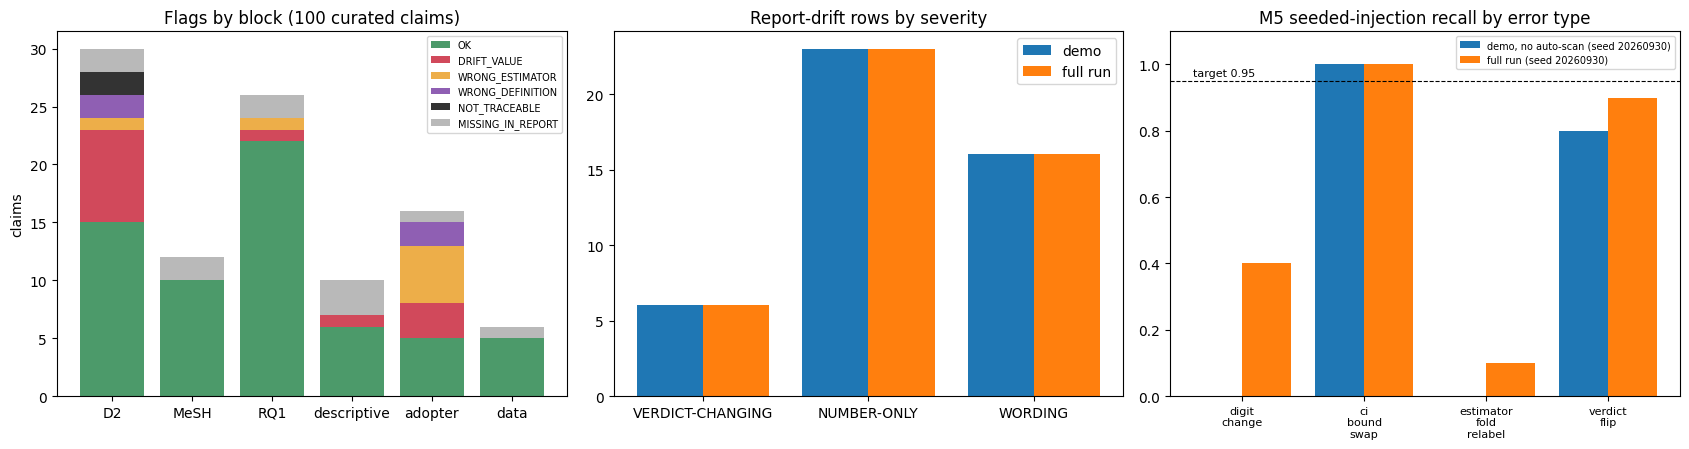


Full-run metrics that need the upstream artifacts (not recomputed here):
  M1_traceability_autoscan_sig2    0.9927206551410374
  M5_precision_manual30            0.8333333333333334
  M6_independent_agreement         1.0
  M6_n_rederived                   73.0
  M7_table_pass_rate               1.0
  M8_review_items_closed           6.0
  M10_missing_in_report_rows       292.0
  M11_table18_done                 3.0
  M11_table18_partial              4.0
  M11_table18_not_done             4.0


In [18]:
# --- 1. per-claim agreement with the original full run
refc = data['reference']['claim_flags']
rows = []
for c in claims:
    r = refc[c['id']]
    rows.append(dict(id=c['id'], block=c['block'], tier=c['tier'], report=c['report_value'], source=fmt(c['source_value']),
                     flag=c['flag'], flag_full_run=r['flag'], same=(c['flag'] == r['flag'] and str(c['report_line']) == str(r['report_line'])
                                                                    and str(c['report_value']) == str(r['report_value']))))
cdf = pd.DataFrame(rows)
print(f"claims whose flag/line/value match the original full run: {cdf.same.sum()}/{len(cdf)}")
pd.set_option('display.max_colwidth', 60); pd.set_option('display.width', 200)
print("\nNon-OK claims (the corrections the paper must use):")
print(cdf[~cdf.flag.isin(['OK', 'MISSING_IN_REPORT'])][['id', 'block', 'tier', 'report', 'source', 'flag']].to_string(index=False))

# --- 2. verdict-changing drift rows
print("\nVERDICT-CHANGING drift rows:")
for r in det['drift']:
    if r['severity'] == 'VERDICT-CHANGING':
        print(f"  line {r['line']:>4} [{r['flag']}] reported {str(r['reported'])[:60]!r}\n        -> {r['correct_text'][:150]}")

# --- 3. seeded injection vs the full run
full_inj = data['reference']['seeded_recall_full']
print(f"\nM5 blind recall: demo (no auto-scan) {inj['recall']:.2f} vs full run {full_inj['recall']:.2f}")

# --- figures
fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))
flag_order = [f for f in AC.FLAGS if any(c['flag'] == f for c in claims)]
blocks = [b for b in BLOCK_ORDER if any(c['block'] == b for c in claims)]
bottom = np.zeros(len(blocks))
colors = dict(OK='#4c9a6a', MISSING_IN_REPORT='#b9b9b9', DRIFT_VALUE='#d1495b', WRONG_ESTIMATOR='#edae49',
              WRONG_DEFINITION='#8f5fb3', NOT_TRACEABLE='#333333', WRONG_FOLD='#00798c', VERDICT_DRIFT='#ff7f0e')
for f in flag_order:
    vals = np.array([sum(1 for c in claims if c['block'] == b and c['flag'] == f) for b in blocks])
    ax[0].bar(blocks, vals, bottom=bottom, label=f, color=colors.get(f))
    bottom += vals
ax[0].set_title(f'Flags by block ({len(claims)} curated claims)'); ax[0].set_ylabel('claims'); ax[0].legend(fontsize=7)

sev_order = ['VERDICT-CHANGING', 'NUMBER-ONLY', 'WORDING']
dem = [sev.get(s, 0) for s in sev_order]
fr = [ref['M4_verdict_changing'], ref['M4_number_only'], ref['M4_wording']]
x = np.arange(3)
ax[1].bar(x - 0.2, dem, 0.4, label='demo'); ax[1].bar(x + 0.2, fr, 0.4, label='full run')
ax[1].set_xticks(x, sev_order); ax[1].set_title('Report-drift rows by severity'); ax[1].legend()

types = list(inj['recall_by_type'])
x = np.arange(len(types))
ax[2].bar(x - 0.2, [inj['recall_by_type'][t] for t in types], 0.4, label=f'demo, no auto-scan (seed {inj["seed"]})')
ax[2].bar(x + 0.2, [full_inj['by_type'].get(t, np.nan) for t in types], 0.4, label=f'full run (seed {full_inj["seed"]})')
ax[2].axhline(0.95, ls='--', c='k', lw=0.8); ax[2].text(-0.4, 0.965, 'target 0.95', fontsize=8)
ax[2].set_xticks(x, [t.replace('_', '\n') for t in types], fontsize=8); ax[2].set_ylim(0, 1.1)
ax[2].set_title('M5 seeded-injection recall by error type'); ax[2].legend(fontsize=7)
plt.tight_layout(); plt.show()

print("\nFull-run metrics that need the upstream artifacts (not recomputed here):")
for k in ['M1_traceability_autoscan_sig2', 'M5_precision_manual30', 'M6_independent_agreement', 'M6_n_rederived', 'M7_table_pass_rate',
          'M8_review_items_closed', 'M10_missing_in_report_rows', 'M11_table18_done', 'M11_table18_partial', 'M11_table18_not_done']:
    print(f"  {k:<32} {ref.get(k)}")